# Этап 4. Градиентный бустинг на основе XGBoost

В этом ноутбуке рассматривается последовательное построение ансамбля с помощью XGBoost.  
XGBoost — это современная реализация градиентного бустинга над деревьями решений. В отличие от классической реализации градиентного бустинга из `sklearn`, XGBoost поддерживает регуляризацию, случайное подвыборочное обучение строк и признаков, а также эффективную оптимизацию.

Именно поэтому для этапа 4 используется `XGBRegressor`, что соответствует плану проекта.


## Импорт библиотек и загрузка данных

Используем уже подготовленные датасеты из первого этапа:

- `train_one_hot_encoded.csv`;
- `validation_one_hot_encoded.csv`;
- `test_one_hot_encoded.csv`.

Целевая переменная `charges` в этих файлах уже логарифмирована через `log1p`, а исходная шкала сохранена в `charges_original`.

In [1]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.base import clone
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import make_scorer
from sklearn.metrics import (
    mean_absolute_error as sklearn_mean_absolute_error,
    root_mean_squared_error as sklearn_root_mean_squared_error,
    r2_score as sklearn_r2_score
)

cwd = Path.cwd()

if (cwd / 'data' / 'processed').exists():
    project_dir = cwd
elif (cwd.parent / 'data' / 'processed').exists():
    project_dir = cwd.parent
else:
    project_dir = Path('..')

processed_dir = project_dir / 'data' / 'processed'
models_dir = project_dir / 'models'
reports_dir = project_dir / 'reports'
figures_dir = reports_dir / 'figures'

models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(processed_dir / 'train_one_hot_encoded.csv')
val_df = pd.read_csv(processed_dir / 'validation_one_hot_encoded.csv')
test_df = pd.read_csv(processed_dir / 'test_one_hot_encoded.csv')

target_col = 'charges'
original_target_col = 'charges_original'
feature_cols = [col for col in train_df.columns if col not in [target_col, original_target_col]]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
y_train_original = train_df[original_target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]
y_val_original = val_df[original_target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]
y_test_original = test_df[original_target_col]

print('Тренировочная выборка:', X_train.shape)
print('Валидационная выборка:', X_val.shape)
print('Тестовая выборка:', X_test.shape)


Тренировочная выборка: (801, 8)
Валидационная выборка: (268, 8)
Тестовая выборка: (268, 8)


## Метрики качества

Модель обучается на `log1p(charges)`, поэтому перед расчетом метрик предсказания нужно возвращать в исходную шкалу через `expm1`.

Используем:

- `R²` — доля объясненной дисперсии;
- `MAE` — средняя абсолютная ошибка;
- `RMSE` — корень из средней квадратичной ошибки, чувствителен к крупным ошибкам.

In [2]:
def inverse_target(values):
    return np.expm1(values)


def r2_original_scale(y_true_log, y_pred_log):
    return sklearn_r2_score(inverse_target(y_true_log), inverse_target(y_pred_log))


r2_original_scorer = make_scorer(r2_original_scale)


def r2_score(y_true_log, y_pred_log):
    return r2_original_scale(y_true_log, y_pred_log)


def mean_absolute_error(y_true_log, y_pred_log):
    return sklearn_mean_absolute_error(inverse_target(y_true_log), inverse_target(y_pred_log))


def root_mean_squared_error(y_true_log, y_pred_log):
    return sklearn_root_mean_squared_error(inverse_target(y_true_log), inverse_target(y_pred_log))


def print_metrics(y_true_log, y_pred_log, title):
    print(title)
    print(f"R2:   {r2_score(y_true_log, y_pred_log):.4f}")
    print(f"MAE:  ${mean_absolute_error(y_true_log, y_pred_log):.2f}")
    print(f"RMSE: ${root_mean_squared_error(y_true_log, y_pred_log):.2f}")

## Идея градиентного бустинга

Градиентный бустинг строит ансамбль последовательно:

1. Первая модель делает начальное приближение.
2. Затем считаются ошибки текущего ансамбля.
3. Новое дерево обучается исправлять эти ошибки.
4. Итоговый прогноз получается как сумма вкладов всех деревьев.

В задачах регрессии это можно понимать как постепенное движение в сторону уменьшения функции потерь. В этом смысле бустинг похож на градиентный спуск, только шаги делаются не по отдельным коэффициентам, а в пространстве функций.

## Псевдо-остатки

Псевдо-остатки — это направление, в котором нужно исправлять текущие предсказания ансамбля.

Для квадратичной ошибки они близки к обычным остаткам:

`факт - прогноз`

На каждом шаге бустинг обучает новое дерево так, чтобы оно предсказывало эти остатки. Поэтому каждое следующее дерево не решает задачу с нуля, а исправляет ошибки уже построенного ансамбля.

## Базовая модель XGBRegressor

Сначала обучим XGBoost с базовыми параметрами. Это даст точку отсчета перед подбором гиперпараметров.


In [3]:
xgb_baseline = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_baseline.fit(X_train, y_train)

xgb_val_pred_baseline = xgb_baseline.predict(X_val)

print_metrics(
    y_val,
    xgb_val_pred_baseline,
    'Базовый XGBRegressor на валидационной выборке'
)


Базовый XGBRegressor на валидационной выборке
R2:   0.8008
MAE:  $3119.28
RMSE: $5506.68


## Основные гиперпараметры XGBoost

В XGBoost особенно важны:

- `n_estimators` — количество деревьев в ансамбле;
- `learning_rate` — размер шага, с которым добавляется новое дерево;
- `max_depth` — глубина каждого отдельного дерева;
- `min_child_weight` — минимальный вес объектов в листе, аналог ограничения сложности разбиений;
- `subsample` — доля объектов для обучения каждого дерева;
- `colsample_bytree` — доля признаков, доступных каждому дереву;
- `reg_lambda` — L2-регуляризация весов листьев;
- `reg_alpha` — L1-регуляризация весов листьев.

Маленький `learning_rate` обычно требует большего числа деревьев, но делает модель устойчивее.


## Двухэтапный подбор гиперпараметров через RandomizedSearchCV

Для бустинга сетка параметров может быть большой, поэтому используем двухэтапный подход.

Сначала выполняется широкий поиск по разным областям параметров. Затем строится уточненный поиск рядом с лучшими найденными значениями. Так мы не перебираем все возможные комбинации, но проверяем перспективную область подробнее.

In [4]:
xgb_cv = KFold(n_splits=5, shuffle=True, random_state=42)

xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_coarse_param_distributions = {
    'n_estimators': [150, 250, 400, 600, 800],
    'learning_rate': [0.01, 0.02, 0.03, 0.05, 0.08],
    'max_depth': [2, 3, 4, 5],
    'min_child_weight': [1, 3, 5, 8],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'reg_lambda': [0.5, 1, 3, 5, 10],
    'reg_alpha': [0, 0.01, 0.1, 0.5]
}

xgb_coarse_random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_coarse_param_distributions,
    n_iter=60,
    scoring=r2_original_scorer,
    cv=xgb_cv,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

xgb_coarse_random_search.fit(X_train, y_train)
xgb_coarse_best_params = xgb_coarse_random_search.best_params_

print('Лучшие параметры после широкого поиска:')
print(xgb_coarse_best_params)
print(f"Лучший средний R2 после широкого поиска: {xgb_coarse_random_search.best_score_:.4f}")

def integer_values_around(best_value, radius, lower_bound, upper_bound):
    values = range(int(best_value) - radius, int(best_value) + radius + 1)
    return [int(value) for value in values if lower_bound <= value <= upper_bound]

def stepped_values_around(best_value, radius, step, lower_bound, upper_bound):
    values = range(int(best_value) - radius, int(best_value) + radius + 1, step)
    result = sorted({int(value) for value in values if lower_bound <= value <= upper_bound})
    if int(best_value) not in result:
        result.append(int(best_value))
    return sorted(result)

def float_values_around(best_value, radius, lower_bound, upper_bound):
    values = [best_value - radius, best_value, best_value + radius]
    return sorted({round(value, 3) for value in values if lower_bound <= value <= upper_bound})

xgb_refined_param_distributions = {
    'n_estimators': stepped_values_around(xgb_coarse_best_params['n_estimators'], radius=150, step=50, lower_bound=100, upper_bound=1000),
    'learning_rate': float_values_around(xgb_coarse_best_params['learning_rate'], radius=0.01, lower_bound=0.005, upper_bound=0.15),
    'max_depth': integer_values_around(xgb_coarse_best_params['max_depth'], radius=1, lower_bound=2, upper_bound=6),
    'min_child_weight': integer_values_around(xgb_coarse_best_params['min_child_weight'], radius=2, lower_bound=1, upper_bound=12),
    'subsample': float_values_around(xgb_coarse_best_params['subsample'], radius=0.1, lower_bound=0.6, upper_bound=1.0),
    'colsample_bytree': float_values_around(xgb_coarse_best_params['colsample_bytree'], radius=0.1, lower_bound=0.6, upper_bound=1.0),
    'reg_lambda': float_values_around(xgb_coarse_best_params['reg_lambda'], radius=1.0, lower_bound=0.0, upper_bound=12.0),
    'reg_alpha': float_values_around(xgb_coarse_best_params['reg_alpha'], radius=0.1, lower_bound=0.0, upper_bound=2.0)
}

xgb_refined_random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_refined_param_distributions,
    n_iter=50,
    scoring=r2_original_scorer,
    cv=xgb_cv,
    random_state=43,
    n_jobs=-1,
    return_train_score=True
)

xgb_refined_random_search.fit(X_train, y_train)

# Дальше используем результат уточненного поиска.
xgb_random_search = xgb_refined_random_search

best_xgb_cv = xgb_random_search.best_estimator_
xgb_val_pred = best_xgb_cv.predict(X_val)

print('\nЛучшие параметры после уточненного поиска:')
print(xgb_random_search.best_params_)
print(f"Лучший средний R2 после уточненного поиска: {xgb_random_search.best_score_:.4f}")
print()
print_metrics(
    y_val,
    xgb_val_pred,
    'Оптимизированный XGBRegressor на валидационной выборке'
)

xgb_coarse_cv_results = pd.DataFrame(xgb_coarse_random_search.cv_results_)
xgb_cv_results = pd.DataFrame(xgb_refined_random_search.cv_results_)
xgb_cv_results[['mean_test_score', 'mean_train_score', 'params']].sort_values(
    by='mean_test_score',
    ascending=False
).head(10)


Лучшие параметры после широкого поиска:
{'subsample': 0.8, 'reg_lambda': 3, 'reg_alpha': 0.1, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
Лучший средний R2 после широкого поиска: 0.8399

Лучшие параметры после уточненного поиска:
{'subsample': 0.9, 'reg_lambda': 4.0, 'reg_alpha': 0.2, 'n_estimators': 700, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Лучший средний R2 после уточненного поиска: 0.8426

Оптимизированный XGBRegressor на валидационной выборке
R2:   0.8705
MAE:  $2082.40
RMSE: $4440.92


,mean_test_score,mean_train_score,params
12,0.842564,0.877062,"{'subsample': 0.9, 'reg_lambda': 4.0, 'reg_alp..."
49,0.841922,0.886746,"{'subsample': 0.9, 'reg_lambda': 4.0, 'reg_alp..."
46,0.841500,0.878564,"{'subsample': 0.7, 'reg_lambda': 4.0, 'reg_alp..."
7,0.841360,0.879204,"{'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alp..."
5,0.841286,0.888928,"{'subsample': 0.7, 'reg_lambda': 4.0, 'reg_alp..."
8,0.840312,0.875557,"{'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alp..."
6,0.839884,0.896024,"{'subsample': 0.9, 'reg_lambda': 4.0, 'reg_alp..."
13,0.839875,0.877636,"{'subsample': 0.7, 'reg_lambda': 4.0, 'reg_alp..."
29,0.839499,0.882594,"{'subsample': 0.9, 'reg_lambda': 2.0, 'reg_alp..."
47,0.839411,0.899913,"{'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alp..."


## Финальная проверка на тестовой выборке

После выбора гиперпараметров обучаем лучшую модель на объединенных `Train + Validation` данных.  
Тестовая выборка используется только на финальном шаге.

In [5]:
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

best_xgb = clone(xgb_random_search.best_estimator_)
best_xgb.fit(X_train_full, y_train_full)

xgb_test_pred = best_xgb.predict(X_test)

print_metrics(
    y_test,
    xgb_test_pred,
    'Финальная проверка XGBRegressor на тестовой выборке'
)

joblib.dump(best_xgb, models_dir / 'xgboost_randomized_search_model.pkl')
print('Модель сохранена:', models_dir / 'xgboost_randomized_search_model.pkl')


Финальная проверка XGBRegressor на тестовой выборке
R2:   0.8579
MAE:  $1885.83
RMSE: $4300.09
Модель сохранена: c:\Users\bulki\OneDrive\Документы\GitHub\Practice_DecisionTreeRegressor\models\xgboost_randomized_search_model.pkl


## Кривые обучения по числу деревьев

Посмотрим, как меняется качество модели при добавлении новых деревьев.  
Если качество на train продолжает расти, а на validation перестает улучшаться или падает, это признак переобучения.

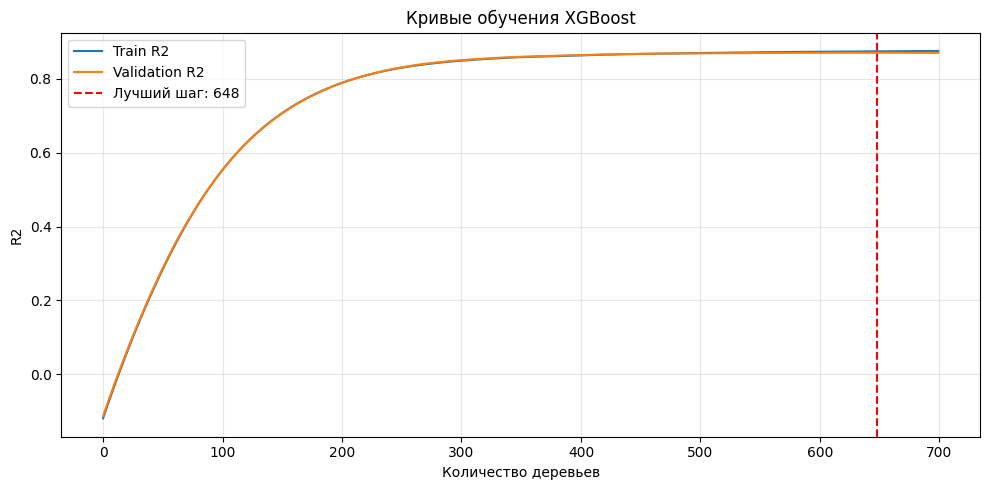

Лучшее количество деревьев по validation: 648
Лучший R2 на validation: 0.8709


In [6]:
xgb_for_learning_curve = clone(xgb_random_search.best_estimator_)
xgb_for_learning_curve.fit(X_train, y_train)

train_r2_by_stage = []
val_r2_by_stage = []
n_estimators = xgb_for_learning_curve.get_params()['n_estimators']

for stage in range(1, n_estimators + 1):
    train_pred_stage = xgb_for_learning_curve.predict(X_train, iteration_range=(0, stage))
    val_pred_stage = xgb_for_learning_curve.predict(X_val, iteration_range=(0, stage))
    train_r2_by_stage.append(r2_score(y_train, train_pred_stage))
    val_r2_by_stage.append(r2_score(y_val, val_pred_stage))

best_stage = int(np.argmax(val_r2_by_stage) + 1)
best_stage_score = max(val_r2_by_stage)

stages = np.arange(1, n_estimators + 1)
check_stages = sorted({400, 500, 600, best_stage, n_estimators})
check_scores = {stage: val_r2_by_stage[stage - 1] for stage in check_stages}

fig, (ax_full, ax_zoom) = plt.subplots(2, 1, figsize=(11, 8), gridspec_kw={'height_ratios': [1, 1.15]})
ax_full.plot(stages, train_r2_by_stage, label='Train R2', color='#377eb8')
ax_full.plot(stages, val_r2_by_stage, label='Validation R2', color='#4daf4a')
ax_full.axvline(best_stage, color='red', linestyle='--', label=f'Максимум validation: {best_stage}')
ax_full.set_title('Качество XGBoost на всех шагах обучения')
ax_full.set_xlabel('Количество деревьев')
ax_full.set_ylabel('R2')
ax_full.legend()
ax_full.grid(True, alpha=0.3)

ax_zoom.plot(stages, val_r2_by_stage, color='#4daf4a', linewidth=2)
for stage, score in check_scores.items():
    is_best = stage == best_stage
    ax_zoom.scatter(stage, score, color='red' if is_best else '#2c7fb8', marker='*' if is_best else 'o', s=120 if is_best else 55, zorder=5)
    ax_zoom.annotate(f'{stage}\nR2={score:.4f}', (stage, score), xytext=(0, 16 if is_best else 12), textcoords='offset points', ha='center', fontsize=9, fontweight='bold' if is_best else 'normal')
ax_zoom.axvline(best_stage, color='red', linestyle='--')
ax_zoom.set_xlim(350, n_estimators + 10)
ax_zoom.set_xticks(check_stages)
ax_zoom.set_title(f'Уточнение: максимум Validation R2 достигается на {best_stage} деревьях')
ax_zoom.set_xlabel('Контрольные значения количества деревьев')
ax_zoom.set_ylabel('Validation R2')
ax_zoom.grid(True, alpha=0.3)

plt.tight_layout(h_pad=2)
plt.savefig(figures_dir / 'xgboost_learning_curve.png', dpi=220, bbox_inches='tight')
plt.show()

print(f"Лучшее количество деревьев по validation: {best_stage}")
print(f"Лучший R2 на validation: {best_stage_score:.4f}")


## Анализ ошибок модели

Построим график остатков. Он показывает, есть ли у модели систематические ошибки и на каких значениях `charges` прогноз становится менее точным.

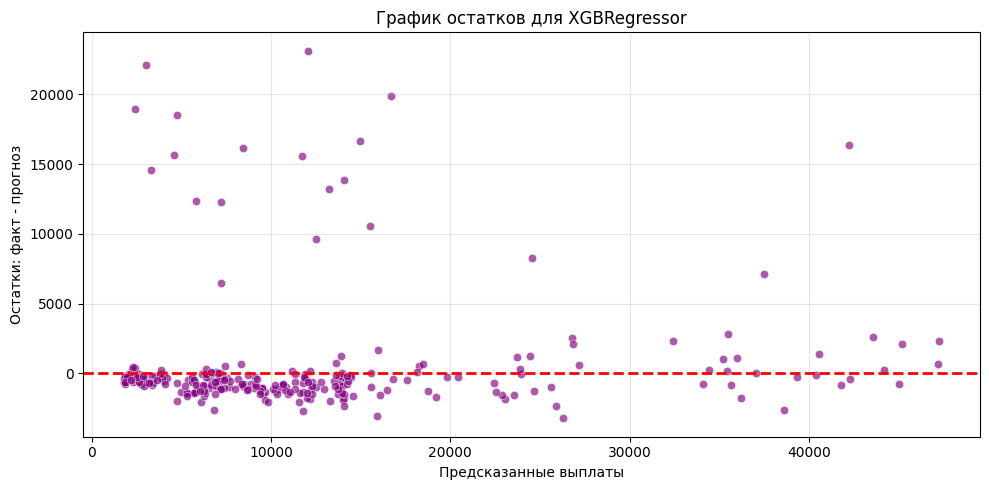

In [7]:
xgb_residuals = inverse_target(y_test) - inverse_target(xgb_test_pred)

plt.figure(figsize=(10, 5))
sns.scatterplot(x=inverse_target(xgb_test_pred), y=xgb_residuals, alpha=0.65, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('График остатков для XGBRegressor')
plt.xlabel('Предсказанные выплаты')
plt.ylabel('Остатки: факт - прогноз')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'xgboost_residuals_test.png', dpi=200, bbox_inches='tight')
plt.show()


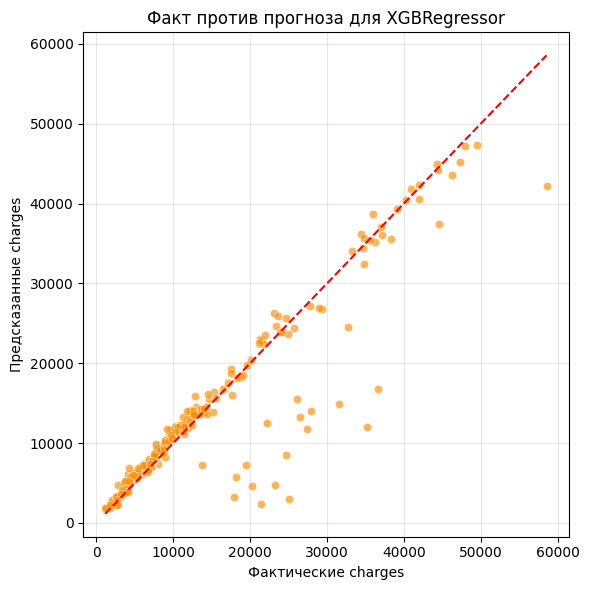

In [8]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=inverse_target(y_test), y=inverse_target(xgb_test_pred), alpha=0.65, color='darkorange')
min_value = min(inverse_target(y_test).min(), inverse_target(xgb_test_pred).min())
max_value = max(inverse_target(y_test).max(), inverse_target(xgb_test_pred).max())
plt.plot([min_value, max_value], [min_value, max_value], color='red', linestyle='--')
plt.title('Факт против прогноза для XGBRegressor')
plt.xlabel('Фактические charges')
plt.ylabel('Предсказанные charges')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'xgboost_actual_vs_predicted.png', dpi=200, bbox_inches='tight')
plt.show()


## Важность признаков

Градиентный бустинг, как и другие модели на основе деревьев, позволяет оценить вклад признаков в построение предсказаний.

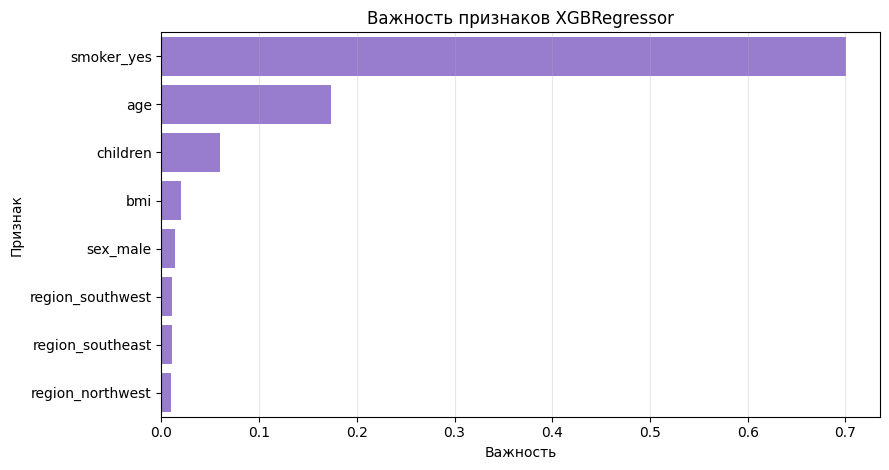

,Признак,Важность
4,smoker_yes,0.700445
0,age,0.173481
2,children,0.060257
1,bmi,0.020098
3,sex_male,0.013916
7,region_southwest,0.011247
6,region_southeast,0.010888
5,region_northwest,0.009668


In [9]:
xgb_feature_importance_df = pd.DataFrame({
    'Признак': X_train.columns,
    'Важность': best_xgb.feature_importances_
}).sort_values(by='Важность', ascending=False)

plt.figure(figsize=(9, 4.8))
sns.barplot(data=xgb_feature_importance_df, x='Важность', y='Признак', color='mediumpurple')
plt.title('Важность признаков XGBRegressor')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'xgboost_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()

xgb_feature_importance_df.to_csv(reports_dir / 'xgboost_feature_importance.csv', index=False, encoding='utf-8')
xgb_feature_importance_df


## Вывод по этапу 4

На этом этапе использовался `XGBRegressor`, то есть реализация градиентного бустинга из библиотеки XGBoost.  
Эта модель строит деревья последовательно: каждое следующее дерево исправляет ошибки уже построенного ансамбля. В отличие от классической реализации градиентного бустинга, XGBoost дополнительно использует регуляризацию и случайный выбор строк/признаков, что помогает контролировать переобучение.

На этом этапе:

1. Была обучена базовая модель `XGBRegressor`.
2. Выполнен двухэтапный подбор гиперпараметров через `RandomizedSearchCV`.
3. Лучшая модель проверена на отложенной тестовой выборке.
4. Построены кривые обучения, график остатков, график `факт против прогноза` и важность признаков.

Итоговое качество нужно сравнить с предыдущими моделями: одиночным деревом, Bagging и Random Forest. Если XGBoost показывает меньший RMSE и более высокий R2, значит последовательное исправление ошибок и регуляризация дали преимущество над простым усреднением деревьев.


In [10]:
xgb_results = {
    'coarse_best_params': xgb_coarse_best_params,
    'coarse_best_score': float(xgb_coarse_random_search.best_score_),
    'refined_best_params': xgb_random_search.best_params_,
    'refined_best_score': float(xgb_random_search.best_score_),
    'validation_metrics': {
        'R2': float(r2_score(y_val, xgb_val_pred)),
        'MAE': float(mean_absolute_error(y_val, xgb_val_pred)),
        'RMSE': float(root_mean_squared_error(y_val, xgb_val_pred)),
    },
    'test_metrics': {
        'R2': float(r2_score(y_test, xgb_test_pred)),
        'MAE': float(mean_absolute_error(y_test, xgb_test_pred)),
        'RMSE': float(root_mean_squared_error(y_test, xgb_test_pred)),
    },
    'best_stage': int(best_stage),
    'best_stage_validation_r2': float(best_stage_score),
    'top_features': xgb_feature_importance_df.head(5).to_dict(orient='records')
}

with open(reports_dir / 'xgboost_results.json', 'w', encoding='utf-8') as f:
    json.dump(xgb_results, f, ensure_ascii=False, indent=2)

xgb_results


{'coarse_best_params': {'subsample': 0.8,
  'reg_lambda': 3,
  'reg_alpha': 0.1,
  'n_estimators': 800,
  'min_child_weight': 3,
  'max_depth': 4,
  'learning_rate': 0.01,
  'colsample_bytree': 0.9},
 'coarse_best_score': 0.8399232150304169,
 'refined_best_params': {'subsample': 0.9,
  'reg_lambda': 4.0,
  'reg_alpha': 0.2,
  'n_estimators': 700,
  'min_child_weight': 5,
  'max_depth': 3,
  'learning_rate': 0.01,
  'colsample_bytree': 1.0},
 'refined_best_score': 0.8425636241151547,
 'validation_metrics': {'R2': 0.8704548773940637,
  'MAE': 2082.4035975691468,
  'RMSE': 4440.923117066386},
 'test_metrics': {'R2': 0.857913244293591,
  'MAE': 1885.8295580572246,
  'RMSE': 4300.092637228809},
 'best_stage': 648,
 'best_stage_validation_r2': 0.8709055018517289,
 'top_features': [{'Признак': 'smoker_yes', 'Важность': 0.700445294380188},
  {'Признак': 'age', 'Важность': 0.17348085343837738},
  {'Признак': 'children', 'Важность': 0.06025692820549011},
  {'Признак': 'bmi', 'Важность': 0.020098